
# Seoul Bike Sharing Demand — ML Analysis

This notebook performs **exploratory data analysis and simple machine learning** on the Seoul Bike Sharing dataset.

Goals:
- Understand the dataset
- Create multiple visualizations
- Perform feature exploration
- Train **simple ML models** (Linear Regression & Decision Tree)

Dataset file expected:
`SeoulBikeData.csv`


## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")


## 2. Load Dataset

In [2]:

df = pd.read_csv("SeoulBikeData.csv", encoding="latin-1")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 3. Basic Data Information

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [4]:

df.describe()


,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## 4. Check Missing Values

In [5]:

df.isnull().sum()


Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

## 5. Distribution of Rented Bike Count

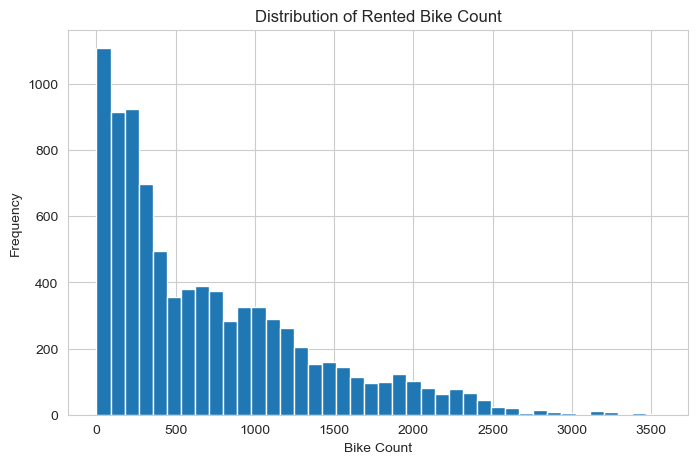

In [6]:

plt.figure(figsize=(8,5))
plt.hist(df['Rented Bike Count'], bins=40)
plt.title("Distribution of Rented Bike Count")
plt.xlabel("Bike Count")
plt.ylabel("Frequency")
plt.show()


## 6. Bike Rentals by Hour

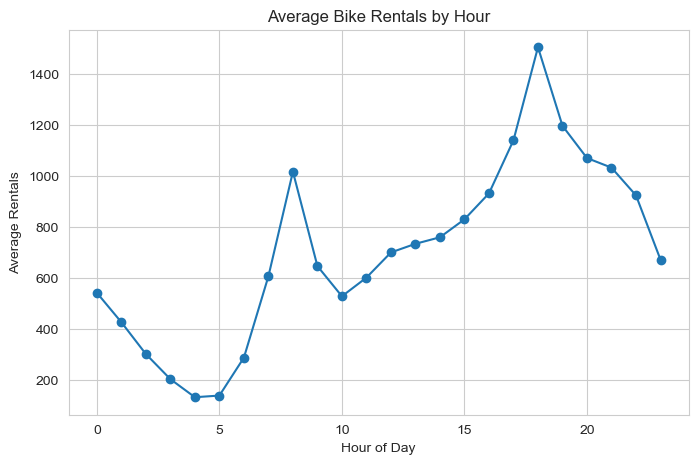

In [7]:

hourly = df.groupby("Hour")["Rented Bike Count"].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly.index, hourly.values, marker='o')
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.show()


## 7. Bike Rentals by Season

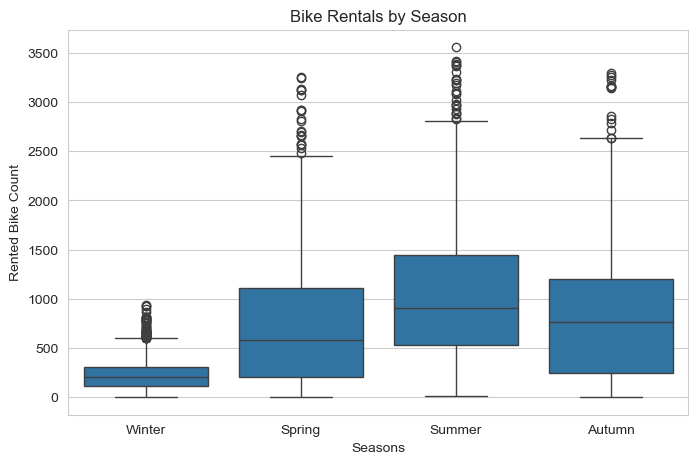

In [8]:

plt.figure(figsize=(8,5))
sns.boxplot(x="Seasons", y="Rented Bike Count", data=df)
plt.title("Bike Rentals by Season")
plt.show()


## 8. Temperature vs Bike Rentals

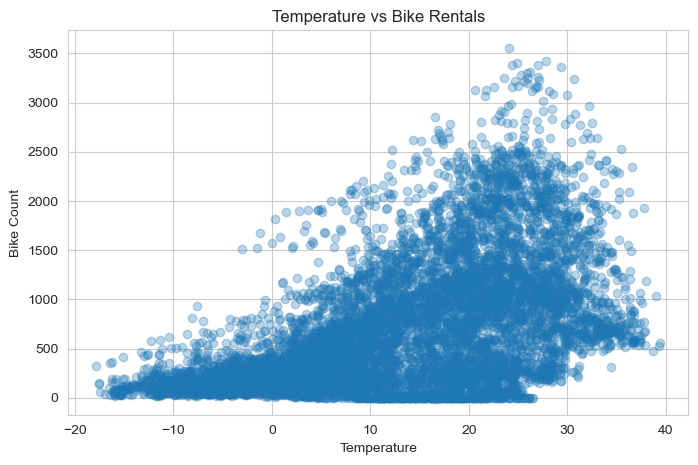

In [9]:

plt.figure(figsize=(8,5))
plt.scatter(df["Temperature(°C)"], df["Rented Bike Count"], alpha=0.3)
plt.title("Temperature vs Bike Rentals")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.show()


## 9. Correlation Heatmap

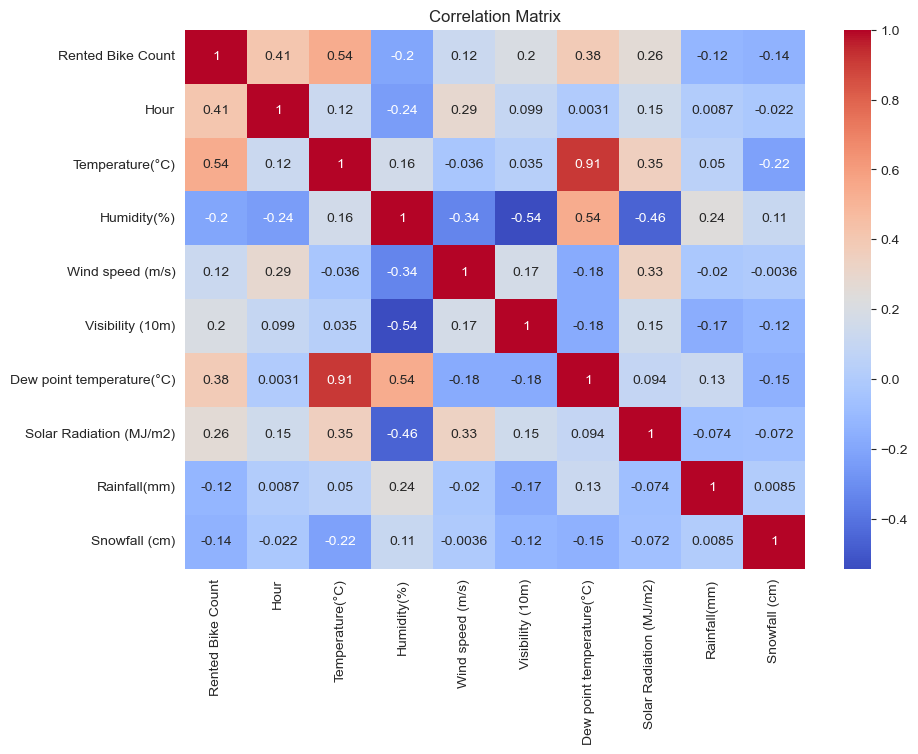

In [10]:

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## 10. Feature Selection

In [11]:

features = [
'Hour',
'Temperature(°C)',
'Humidity(%)',
'Wind speed (m/s)',
'Visibility (10m)',
'Solar Radiation (MJ/m2)',
'Rainfall(mm)',
'Snowfall (cm)'
]

X = df[features]
y = df["Rented Bike Count"]


## 11. Train Test Split

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (7008, 8)
Test size: (1752, 8)


## 12. Linear Regression Model

In [13]:

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.46490801539292637
RMSE: 472.1695269863129


### Prediction vs Actual

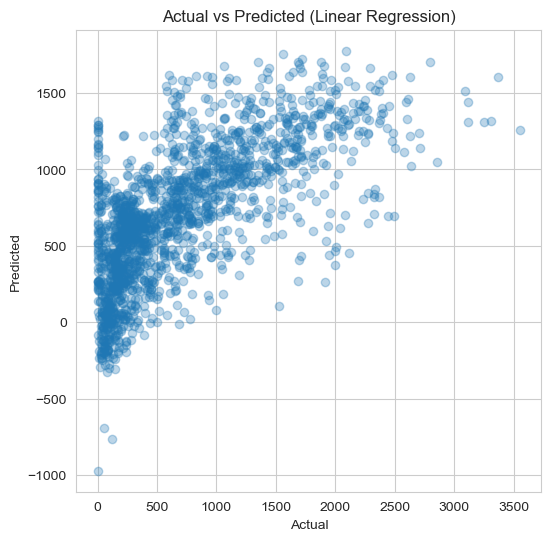

In [14]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()


## 13. Decision Tree Model

In [15]:

tree = DecisionTreeRegressor(max_depth=6)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))


R2 Score: 0.669358052257411
RMSE: 371.16131742887694


### Decision Tree Predictions

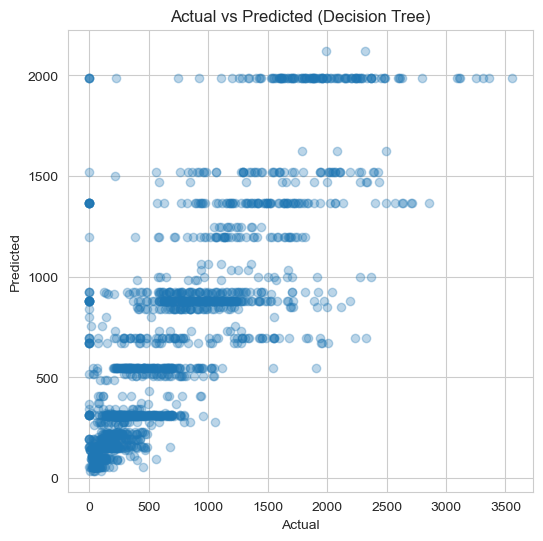

In [16]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_tree, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Decision Tree)")
plt.show()



## 14. Conclusion

This notebook demonstrated:

- Data exploration with multiple charts
- Feature relationships
- Simple machine learning models
- Model evaluation

Models used:
- Linear Regression
- Decision Tree Regressor
